# MNIST Optimiser Comparison: SVD-SGD vs Adam vs SGD

This notebook compares three optimisers on the MNIST digit classification task:
- Standard SGD
- Adam
- Custom SVD-SGD optimizer

We use cross-entropy loss for multi-class classification.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import optax
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import flax.linen as nn
from typing import List, Callable
from datasets import load_dataset
from svd_optimiser import svd_sgd

# Set random seeds for reproducibility
np.random.seed(42)

## Load MNIST Dataset

Loading MNIST dataset...
Training set size: 60000
Test set size: 10000
Input dimension: 784
Number of classes: 10


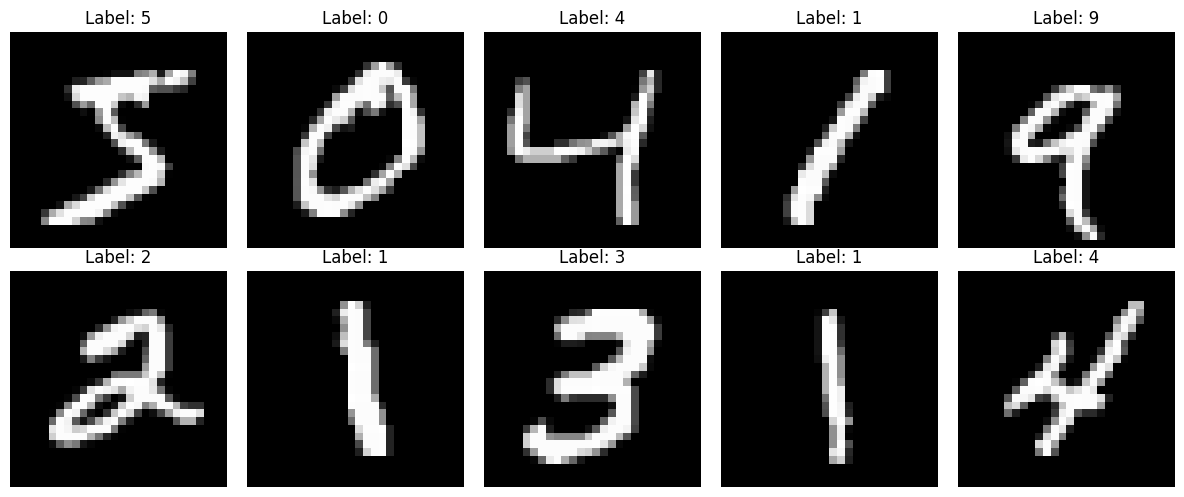

In [2]:
# Load MNIST dataset using the datasets package
print("Loading MNIST dataset...")
dataset = load_dataset("mnist")

# Extract training and test data
train_data = dataset['train']
test_data = dataset['test']

# Convert to numpy arrays and normalize
X_train = np.array([np.array(img).flatten() for img in train_data['image']]) / 255.0
y_train = np.array(train_data['label'])

X_test = np.array([np.array(img).flatten() for img in test_data['image']]) / 255.0
y_test = np.array(test_data['label'])

# Convert to JAX arrays
X_train = jnp.array(X_train)
y_train = jnp.array(y_train)
X_test = jnp.array(X_test)
y_test = jnp.array(y_test)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Input dimension: {X_train.shape[1]}")
print(f"Number of classes: {len(np.unique(y_train))}")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()

## Define Model Architecture

In [3]:
class MLP(nn.Module):
    hidden_layers: List[int]
    output_dim: int
    activation: Callable = nn.gelu

    @nn.compact
    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        for units in self.hidden_layers:
            x = nn.Dense(units)(x)
            x = self.activation(x)
        x = nn.Dense(self.output_dim, use_bias=False)(x)
        return x

# Initialize model
key = jax.random.PRNGKey(42)
hidden_layers = [32, 32]
output_dim = 10  # 10 classes for MNIST
input_dim = 784  # 28x28 pixels

model = MLP(hidden_layers=hidden_layers, output_dim=output_dim)
params_initial = model.init(key, jnp.ones((1, input_dim)))

print(f"Model architecture: {input_dim} -> {' -> '.join(map(str, hidden_layers))} -> {output_dim}")

Model architecture: 784 -> 32 -> 32 -> 10


## Define Loss Functions and Metrics

In [4]:
def cross_entropy_loss(logits, labels):
    """Compute cross-entropy loss."""
    log_probs = jax.nn.log_softmax(logits, axis=-1)
    one_hot_labels = jax.nn.one_hot(labels, num_classes=10)
    loss = -jnp.mean(jnp.sum(one_hot_labels * log_probs, axis=-1))
    return loss

def loss_fn(params, X, y):
    """Loss function for gradient-based optimisers."""
    logits = model.apply(params, X)
    return cross_entropy_loss(logits, y)

@jax.jit
def compute_accuracy(params, X, y):
    """Compute classification accuracy."""
    logits = model.apply(params, X)
    predictions = jnp.argmax(logits, axis=-1)
    return jnp.mean(predictions == y)

@jax.jit
def evaluate(params, X, y):
    """Evaluate both loss and accuracy."""
    logits = model.apply(params, X)
    loss = cross_entropy_loss(logits, y)
    accuracy = jnp.mean(jnp.argmax(logits, axis=-1) == y)
    return loss, accuracy

## Training with Standard SGD

In [5]:
# Initialise parameters for SGD
params_sgd = jax.tree.map(lambda x: x.copy(), params_initial)

# Define SGD optimiser
learning_rate_sgd = 0.01
optimizer_sgd = optax.sgd(learning_rate_sgd)
opt_state_sgd = optimizer_sgd.init(params_sgd)

@jax.jit
def train_step_sgd(params, opt_state, X, y):
    loss, grads = jax.value_and_grad(loss_fn)(params, X, y)
    updates, opt_state = optimizer_sgd.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# Training loop for SGD
batch_size = 256
epochs = 50
num_batches = len(X_train) // batch_size

train_losses_sgd = []
train_accs_sgd = []
val_losses_sgd = []
val_accs_sgd = []

print("Training with SGD...")
for epoch in tqdm(range(epochs)):
    # Shuffle data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    epoch_loss = 0.0
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = start_idx + batch_size
        
        batch_X = X_train_shuffled[start_idx:end_idx]
        batch_y = y_train_shuffled[start_idx:end_idx]
        
        params_sgd, opt_state_sgd, loss_value = train_step_sgd(params_sgd, opt_state_sgd, batch_X, batch_y)
        epoch_loss += loss_value
    
    # Calculate metrics
    avg_train_loss = epoch_loss / num_batches
    train_acc = compute_accuracy(params_sgd, X_train, y_train)
    val_loss, val_acc = evaluate(params_sgd, X_test, y_test)
    
    train_losses_sgd.append(avg_train_loss)
    train_accs_sgd.append(train_acc)
    val_losses_sgd.append(val_loss)
    val_accs_sgd.append(val_acc)

print(f"\nSGD - Final Train Accuracy: {train_accs_sgd[-1]:.4f}, Val Accuracy: {val_accs_sgd[-1]:.4f}")
print(f"SGD - Final Train Loss: {train_losses_sgd[-1]:.4f}, Val Loss: {val_losses_sgd[-1]:.4f}")

Training with SGD...


  0%|          | 0/50 [00:00<?, ?it/s]


SGD - Final Train Accuracy: 0.9424, Val Accuracy: 0.9404
SGD - Final Train Loss: 0.2001, Val Loss: 0.2016


## Training with Adam

In [6]:
# Initialise parameters for Adam
params_adam = jax.tree.map(lambda x: x.copy(), params_initial)

# Define Adam optimiser
learning_rate_adam = 0.001
optimizer_adam = optax.adam(learning_rate_adam)
opt_state_adam = optimizer_adam.init(params_adam)

@jax.jit
def train_step_adam(params, opt_state, X, y):
    loss, grads = jax.value_and_grad(loss_fn)(params, X, y)
    updates, opt_state = optimizer_adam.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

# Training loop for Adam
train_losses_adam = []
train_accs_adam = []
val_losses_adam = []
val_accs_adam = []

print("Training with Adam...")
for epoch in tqdm(range(epochs)):
    # Shuffle data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    epoch_loss = 0.0
    
    for batch_idx in range(num_batches):
        start_idx = batch_idx * batch_size
        end_idx = start_idx + batch_size
        
        batch_X = X_train_shuffled[start_idx:end_idx]
        batch_y = y_train_shuffled[start_idx:end_idx]
        
        params_adam, opt_state_adam, loss_value = train_step_adam(params_adam, opt_state_adam, batch_X, batch_y)
        epoch_loss += loss_value
    
    # Calculate metrics
    avg_train_loss = epoch_loss / num_batches
    train_acc = compute_accuracy(params_adam, X_train, y_train)
    val_loss, val_acc = evaluate(params_adam, X_test, y_test)
    
    train_losses_adam.append(avg_train_loss)
    train_accs_adam.append(train_acc)
    val_losses_adam.append(val_loss)
    val_accs_adam.append(val_acc)

print(f"\nAdam - Final Train Accuracy: {train_accs_adam[-1]:.4f}, Val Accuracy: {val_accs_adam[-1]:.4f}")
print(f"Adam - Final Train Loss: {train_losses_adam[-1]:.4f}, Val Loss: {val_losses_adam[-1]:.4f}")

Training with Adam...


  0%|          | 0/50 [00:00<?, ?it/s]


Adam - Final Train Accuracy: 0.9949, Val Accuracy: 0.9653
Adam - Final Train Loss: 0.0210, Val Loss: 0.1524


## Training with SVD-SGD

In [10]:
# Initialise parameters for SVD-SGD
params_svd = jax.tree.map(lambda x: x.copy(), params_initial)

# Define SVD-SGD optimiser
learning_rate_svd = 0.1
num_svd = 50
rtol = 1e-3

optimizer_svd = svd_sgd(learning_rate=learning_rate_svd, num_svd=num_svd, rtol=rtol, svd_key=jax.random.PRNGKey(42))
opt_state_svd = optimizer_svd.init(params_svd)

# Define functions for SVD-SGD
def compute_batched_grads(params, X):
    """Compute gradient for each sample in the batch."""
    def scalar_model_apply(params, x):
        logits = model.apply(params, x)
        # For multi-class, we'll compute Jacobian for each class
        return logits
    
    # jacrev computes full Jacobian
    jac_fn = jax.jacrev(scalar_model_apply, argnums=0)
    jacobian_tree = jax.vmap(jac_fn, in_axes=(None, 0))(params, X)
    
    return jacobian_tree

def compute_per_sample_grads_and_losses(params, X, y):
    """Compute per-sample gradients and losses for classification."""
    def single_sample_loss_and_grad(params, x, label):
        def loss_single(p):
            logits = model.apply(p, x.reshape(1, -1))
            log_probs = jax.nn.log_softmax(logits, axis=-1)
            one_hot = jax.nn.one_hot(label, num_classes=10)
            return -jnp.sum(one_hot * log_probs)
        
        loss = loss_single(params)
        grad = jax.grad(loss_single)(params)
        return grad, loss
    
    # Vectorise over the batch
    grads_batched, losses_batched = jax.vmap(
        single_sample_loss_and_grad, 
        in_axes=(None, 0, 0)
    )(params, X, y)
    
    return grads_batched, losses_batched

@jax.jit
def train_step_svd(params, opt_state, X, y):
    """Training step using the custom SVD optimiser."""
    # Compute batched gradients and losses
    grads_batched, loss_batched = compute_per_sample_grads_and_losses(params, X, y)
    
    # Update using the custom optimiser
    updates, opt_state = optimizer_svd.update(grads_batched, loss_batched, opt_state, params)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state

In [11]:
# Training loop for SVD-SGD
batch_size_svd = 64  # Smaller batch size for SVD method
num_batches_svd = len(X_train) // batch_size_svd

train_losses_svd = []
train_accs_svd = []
val_losses_svd = []
val_accs_svd = []

print("Training with SVD-SGD...")
for epoch in tqdm(range(epochs)):
    # Shuffle data
    indices = np.random.permutation(len(X_train))
    X_train_shuffled = X_train[indices]
    y_train_shuffled = y_train[indices]
    
    for batch_idx in range(num_batches_svd):
        start_idx = batch_idx * batch_size_svd
        end_idx = start_idx + batch_size_svd
        
        batch_X = X_train_shuffled[start_idx:end_idx]
        batch_y = y_train_shuffled[start_idx:end_idx]
        
        params_svd, opt_state_svd = train_step_svd(params_svd, opt_state_svd, batch_X, batch_y)
    
    # Calculate metrics
    train_loss, train_acc = evaluate(params_svd, X_train, y_train)
    val_loss, val_acc = evaluate(params_svd, X_test, y_test)
    
    train_losses_svd.append(train_loss)
    train_accs_svd.append(train_acc)
    val_losses_svd.append(val_loss)
    val_accs_svd.append(val_acc)

print(f"\nSVD-SGD - Final Train Accuracy: {train_accs_svd[-1]:.4f}, Val Accuracy: {val_accs_svd[-1]:.4f}")
print(f"SVD-SGD - Final Train Loss: {train_losses_svd[-1]:.4f}, Val Loss: {val_losses_svd[-1]:.4f}")

Training with SVD-SGD...


  0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Comparison of All Methods

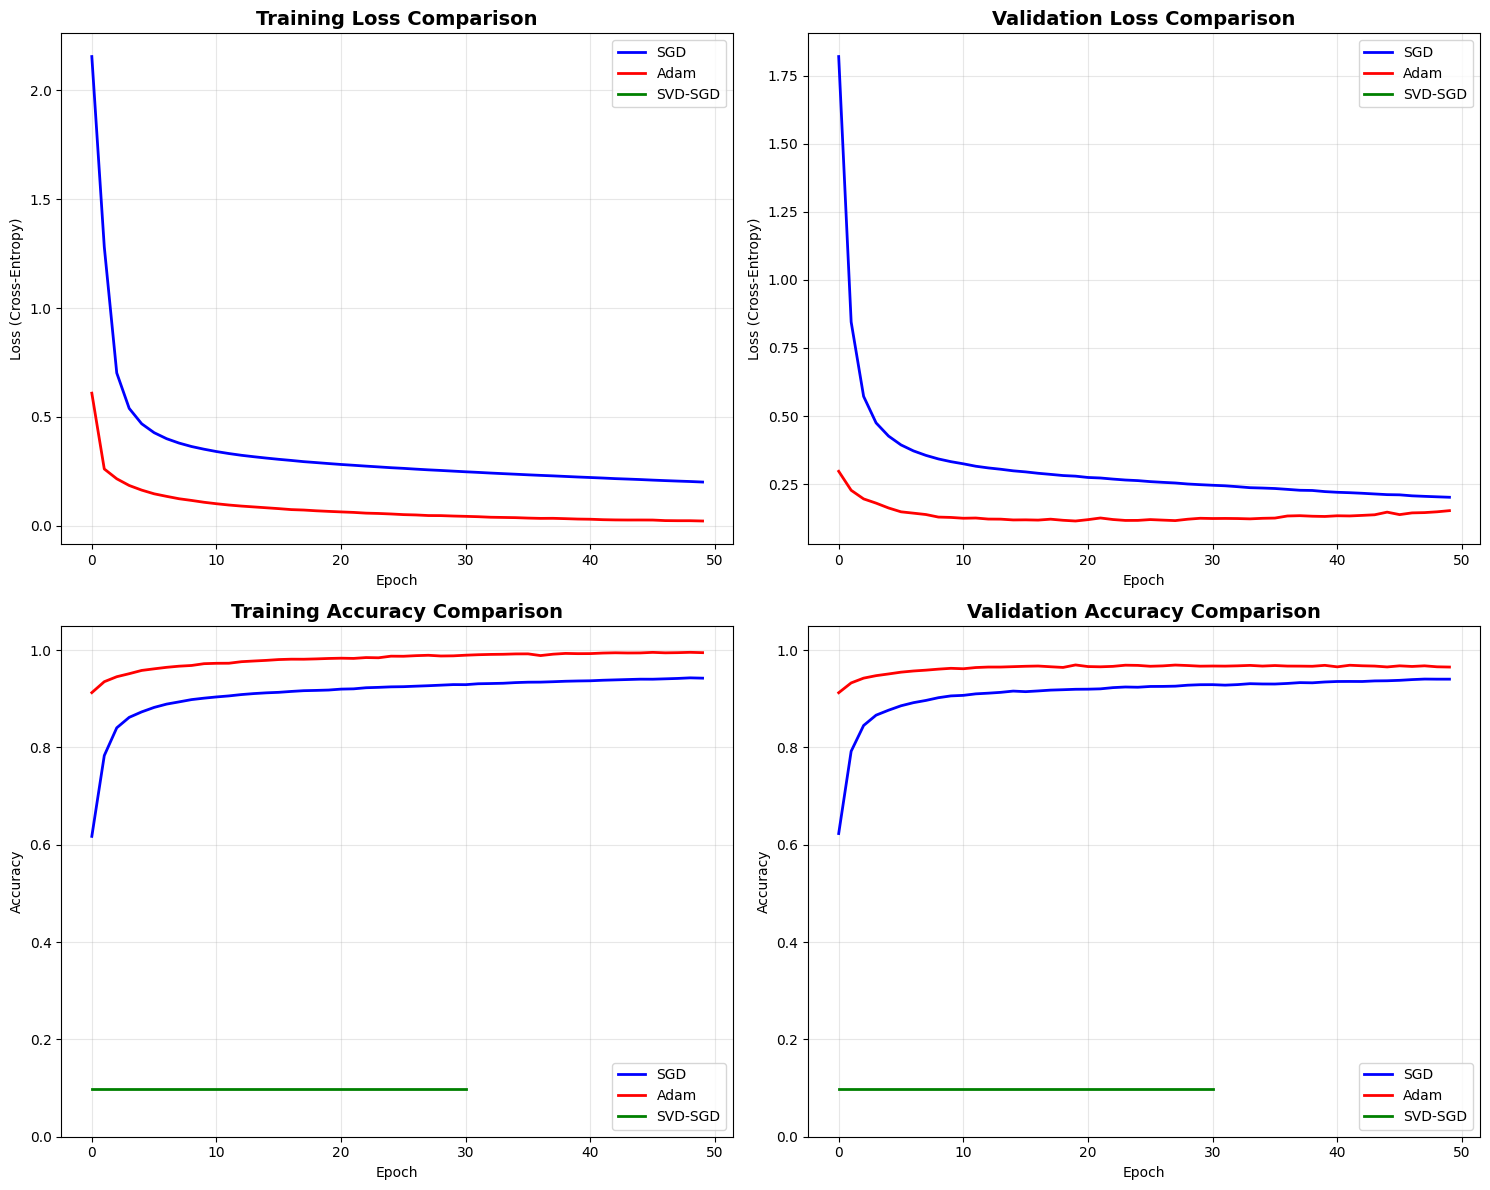

In [12]:
# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Training Loss
axes[0, 0].plot(train_losses_sgd, label='SGD', color='blue', linewidth=2)
axes[0, 0].plot(train_losses_adam, label='Adam', color='red', linewidth=2)
axes[0, 0].plot(train_losses_svd, label='SVD-SGD', color='green', linewidth=2)
axes[0, 0].set_title('Training Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss (Cross-Entropy)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Validation Loss
axes[0, 1].plot(val_losses_sgd, label='SGD', color='blue', linewidth=2)
axes[0, 1].plot(val_losses_adam, label='Adam', color='red', linewidth=2)
axes[0, 1].plot(val_losses_svd, label='SVD-SGD', color='green', linewidth=2)
axes[0, 1].set_title('Validation Loss Comparison', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss (Cross-Entropy)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Training Accuracy
axes[1, 0].plot(train_accs_sgd, label='SGD', color='blue', linewidth=2)
axes[1, 0].plot(train_accs_adam, label='Adam', color='red', linewidth=2)
axes[1, 0].plot(train_accs_svd, label='SVD-SGD', color='green', linewidth=2)
axes[1, 0].set_title('Training Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy')
axes[1, 0].set_ylim([0, 1.05])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Validation Accuracy
axes[1, 1].plot(val_accs_sgd, label='SGD', color='blue', linewidth=2)
axes[1, 1].plot(val_accs_adam, label='Adam', color='red', linewidth=2)
axes[1, 1].plot(val_accs_svd, label='SVD-SGD', color='green', linewidth=2)
axes[1, 1].set_title('Validation Accuracy Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_ylim([0, 1.05])
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# Print final comparison table
print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(f"{'Optimiser':<15} {'Train Loss':<15} {'Val Loss':<15} {'Train Acc':<15} {'Val Acc':<15}")
print("-"*80)
print(f"{'SGD':<15} {train_losses_sgd[-1]:<15.6f} {val_losses_sgd[-1]:<15.6f} {train_accs_sgd[-1]:<15.6f} {val_accs_sgd[-1]:<15.6f}")
print(f"{'Adam':<15} {train_losses_adam[-1]:<15.6f} {val_losses_adam[-1]:<15.6f} {train_accs_adam[-1]:<15.6f} {val_accs_adam[-1]:<15.6f}")
print(f"{'SVD-SGD':<15} {train_losses_svd[-1]:<15.6f} {val_losses_svd[-1]:<15.6f} {train_accs_svd[-1]:<15.6f} {val_accs_svd[-1]:<15.6f}")
print("="*80)


FINAL RESULTS SUMMARY
Optimiser       Train Loss      Val Loss        Train Acc       Val Acc        
--------------------------------------------------------------------------------
SGD             0.200093        0.201585        0.942450        0.940400       
Adam            0.020996        0.152376        0.994850        0.965300       
SVD-SGD         nan             nan             0.098717        0.098000       


## Visualize Predictions

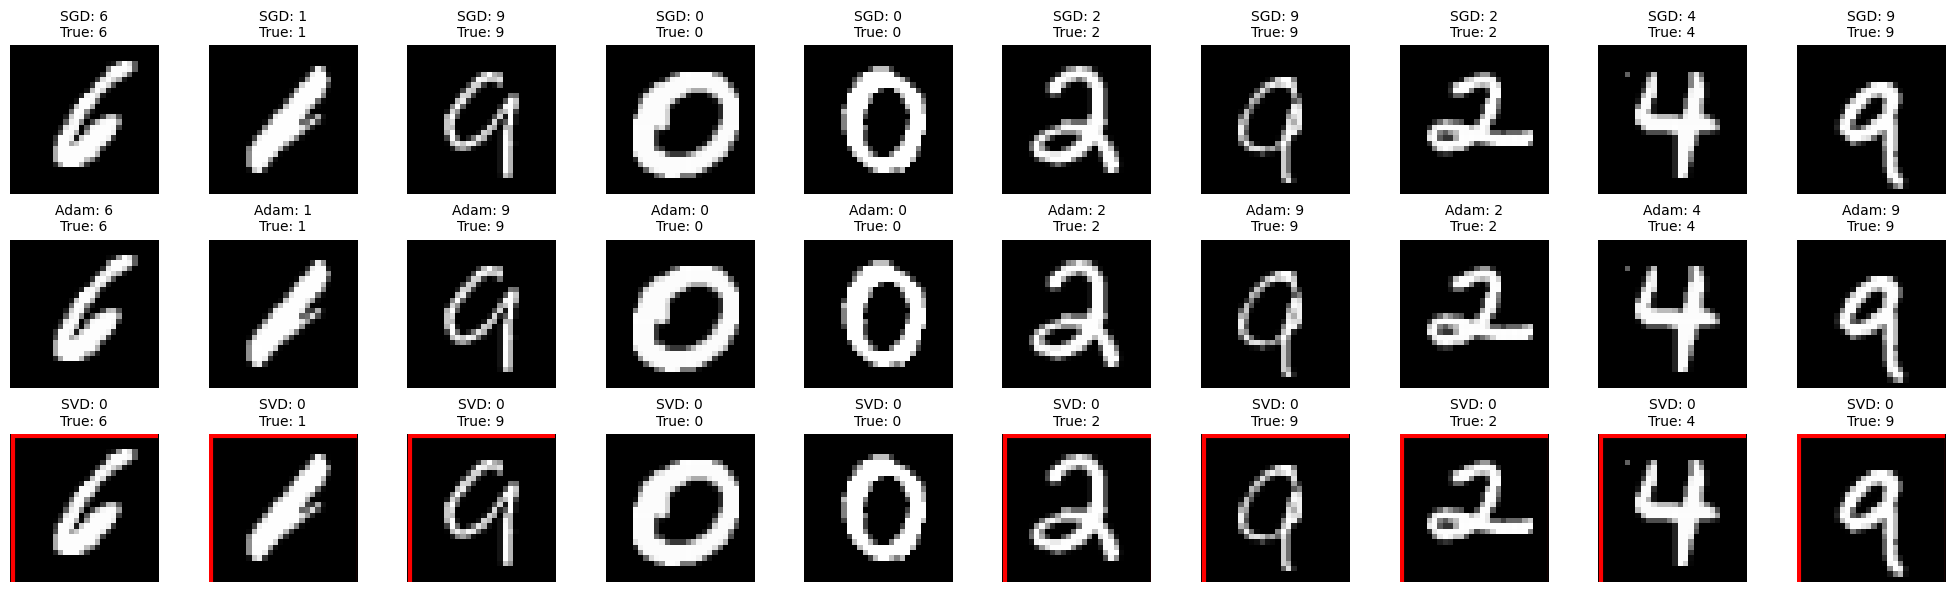

In [14]:
# Visualise some predictions from each optimiser
num_samples = 10
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(3, num_samples, figsize=(20, 6))

# Get predictions from all optimisers
logits_sgd = model.apply(params_sgd, X_test[sample_indices])
preds_sgd = jnp.argmax(logits_sgd, axis=-1)

logits_adam = model.apply(params_adam, X_test[sample_indices])
preds_adam = jnp.argmax(logits_adam, axis=-1)

logits_svd = model.apply(params_svd, X_test[sample_indices])
preds_svd = jnp.argmax(logits_svd, axis=-1)

# Plot predictions
for i in range(num_samples):
    # SGD
    axes[0, i].imshow(X_test[sample_indices[i]].reshape(28, 28), cmap='gray')
    axes[0, i].set_title(f"SGD: {preds_sgd[i]}\nTrue: {y_test[sample_indices[i]]}", fontsize=10)
    axes[0, i].axis('off')
    if preds_sgd[i] != y_test[sample_indices[i]]:
        axes[0, i].add_patch(plt.Rectangle((0, 0), 28, 28, fill=False, edgecolor='red', linewidth=3))
    
    # Adam
    axes[1, i].imshow(X_test[sample_indices[i]].reshape(28, 28), cmap='gray')
    axes[1, i].set_title(f"Adam: {preds_adam[i]}\nTrue: {y_test[sample_indices[i]]}", fontsize=10)
    axes[1, i].axis('off')
    if preds_adam[i] != y_test[sample_indices[i]]:
        axes[1, i].add_patch(plt.Rectangle((0, 0), 28, 28, fill=False, edgecolor='red', linewidth=3))
    
    # SVD-SGD
    axes[2, i].imshow(X_test[sample_indices[i]].reshape(28, 28), cmap='gray')
    axes[2, i].set_title(f"SVD: {preds_svd[i]}\nTrue: {y_test[sample_indices[i]]}", fontsize=10)
    axes[2, i].axis('off')
    if preds_svd[i] != y_test[sample_indices[i]]:
        axes[2, i].add_patch(plt.Rectangle((0, 0), 28, 28, fill=False, edgecolor='red', linewidth=3))

# Add row labels
axes[0, 0].set_ylabel('SGD', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Adam', fontsize=12, fontweight='bold')
axes[2, 0].set_ylabel('SVD-SGD', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()